# Traitez les images pour le système embarqué d’une voiture autonome : Modèle

Ce projet vise à développer un modèle capable de de reconnaître différent indice visuel dans un cas de voiture autonome. Notre jeu de données est disponible à ce lien: www.cityscapes-dataset.com/dataset-overview/. Les deux dossiers que nous récupérons sont celui avec les images non modifiés (leftImg8bit), et celui déjà traité avec un masque (gtFine). Ils contiennent les même images mais avec un traitement différent. Le premier agira comme nos variables prédicatives, et le deuxième est notre cible.

## Import

In [1]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

## Récupération des données

### Exploration

Nous allons commencer par regarder les images que nous avons pour en apprendre plus sur ces dernières.

In [2]:
img_path = "data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000009_000019_leftImg8bit.png"
mask_path = img_path.replace("leftImg8bit", "gtFine")
mask_path = mask_path.replace(".png", "_labelIds.png")
img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

print(img.shape, mask.shape)

(1024, 2048, 3) (1024, 2048)


Les deux types d'images qui nous intéressent sont toutes deux en format 1024 X 2048 et les images non traité ont un dimension en plus contenant les valeurs rgb.

Il serait bien de savoir la distribution des labels dans la base de données. Effectivement, si un des labels est très rare, il pourrait présager d'une mauvaise performance d'un modèle sur ce label, car il ne le verrait pas assez. Nous avons trouvé la liste suivante dans le GitHub lié au jeu de données, nous allons pouvoir l'utiliser pour traduire les labels.

<font color='red'>Note: Dans l'intitulé, il est demander de n'utiliser que les 8 catégories, nous allons donc traduire nos labels en catégories. Cependant, cela fonctionne pour certaines catégories mais pas pour d'autre. Effectivement, "road" et "sidewalk" sont tout deux dans la catégorie "flat", cependant il ne doivent pas être traiter de la même façon par un modèle de décision. Ce point là serait donc à revoir si on voulait vraiment utilisé notre modèle.</font>

In [3]:
import glob
from tqdm import tqdm
import os

LABELS=[
	('unlabeled', 0, 'void', 0),
	('egovehicle', 1, 'void', 0),
	('rectificationborder', 2, 'void', 0),
	('outofroi', 3, 'void', 0),
	('static', 4, 'void', 0),
	('dynamic', 5, 'void', 0),
	('ground', 6, 'void', 0),
	('road', 7, 'flat', 1),
	('sidewalk', 8, 'flat', 1),
	('parking', 9, 'flat', 1),
	('railtrack', 10, 'flat', 1),
	('building', 11, 'construction', 2),
	('wall', 12, 'construction', 2),
	('fence', 13, 'construction', 2),
	('guardrail', 14, 'construction', 2),
	('bridge', 15, 'construction', 2),
	('tunnel', 16, 'construction', 2),
	('pole', 17, 'object', 3),
	('polegroup', 18, 'object', 3),
	('trafficlight', 19, 'object', 3),
	('trafficsign', 20, 'object', 3),
	('vegetation', 21, 'nature', 4),
	('terrain', 22, 'nature', 4),
	('sky', 23, 'sky', 5),
	('person', 24, 'human', 6),
	('rider', 25, 'human', 6),
	('car', 26, 'vehicle', 7),
	('truck', 27, 'vehicle', 7),
	('bus', 28, 'vehicle', 7),
	('caravan', 29, 'vehicle', 7),
	('trailer', 30, 'vehicle', 7),
	('train', 31, 'vehicle', 7),
	('motorcycle', 32, 'vehicle', 7),
	('bicycle', 33, 'vehicle', 7)
]

total_pxl_count = np.zeros(LABELS[-1][3] + 1)

folder_types = ("train", "val")

MAPPING_ARRAY = np.array([x[3] for x in LABELS])

OUTPUTS_DIR = "outputs"
if not os.path.exists(OUTPUTS_DIR):
	os.makedirs(OUTPUTS_DIR)

PXL_COUNT_FILE = os.path.join(OUTPUTS_DIR, "pixel_count.npy")

if os.path.exists(PXL_COUNT_FILE):
	total_pxl_count = np.load(PXL_COUNT_FILE)

else:
	for folder_type in folder_types:
		mask_folder = f"data/P8_Cityscapes_gtFine_trainvaltest/gtFine/{folder_type}/*/*labelIds*"
		for img_path in tqdm(glob.glob(mask_folder)):
			mask_array = np.array(Image.open(img_path))
			mask_catg = MAPPING_ARRAY[mask_array]

			unique_ids, counts = np.unique(mask_catg, return_counts=True)

			for id_val, count in zip(unique_ids, counts):
				total_pxl_count[id_val] += count
	
	np.save(PXL_COUNT_FILE, total_pxl_count)

biggest_count = sum(total_pxl_count)
prct_pxl_count = (total_pxl_count / biggest_count) * 100
print(prct_pxl_count)

[10.50363089 38.72925688 21.71710588  1.80807399 15.23445401  3.46814976
  1.21684186  7.32248673]


Maintenant que nous avons les pourcentages, affichons les sur un graphique pour les comparés.

/home/titouan/Documents/Open Classrooms/Projets/p8/IAEngP8/.venv/lib/python3.12/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


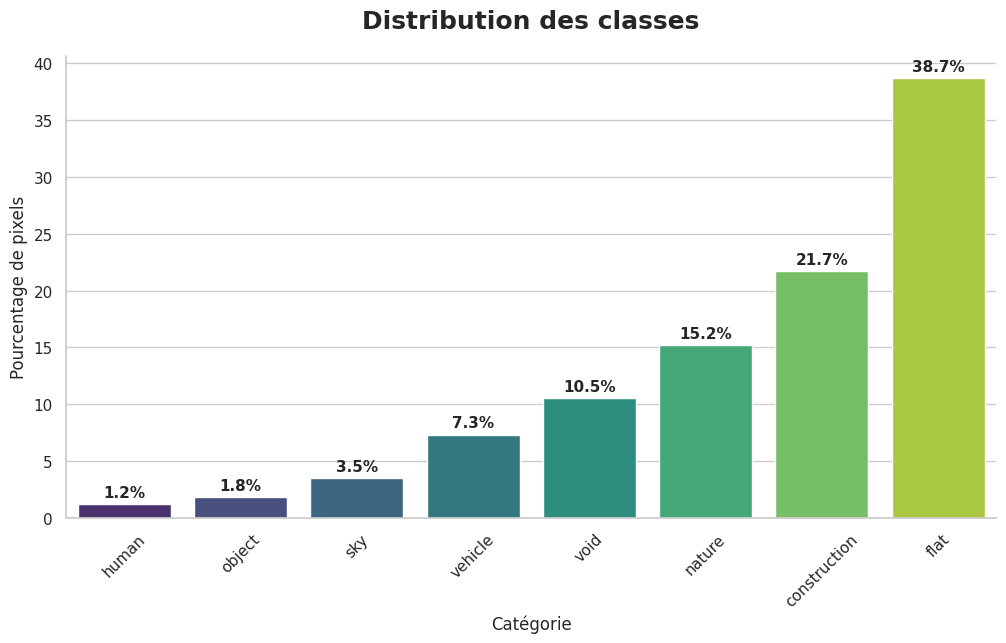

In [4]:
import seaborn as sns
import polars as pl

catg_dict = {row[3]:row[2] for row in LABELS}
catg_name = [catg_dict[i] for i in range(len(catg_dict))]

df_distrib = pl.DataFrame({
	'Classe': catg_name,
	'Pourcentage': prct_pxl_count
})

df_distrib = df_distrib.sort('Pourcentage')

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
	data=df_distrib, 
	x='Classe',
	y='Pourcentage',
	palette="viridis",
	hue='Classe',
	legend=False
)

for i in ax.containers:
	ax.bar_label(i, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold') # type: ignore

plt.title("Distribution des classes", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Pourcentage de pixels", fontsize=12)
plt.xlabel("Catégorie", fontsize=12)
plt.xticks(rotation=45)
sns.despine()

plt.show()

Nous remarquons que certaines catégories sont beaucoup moins présentes que d'autres. Ceci peut représenter un problème, car notre modèle aura tendance à très rarement prédire nos données peu présente. De plus, ici ce sont les humains qui sont peu présent, et il serait dramatique de les confondres avec de la route. Pour pallier ce problème, nous pourrons ajouter des poids lors de notre entraînement pour que les erreurs faites sur la mauvaise interprétation d'humains et d'objet soit grave, et que donc notre modèle est moins tendance à faire cette erreur.

### Réduction des labels

Nous avons appris dans la description des données qu'il y avaient 35 labels en tout ranger dans 8 catégories. Le système de décision n'aura besoin que des 8 catégories, nous pouvons donc réduire la taille des labels possibles, ce qui va nous permettre d'accélerer la vitesse du modèle et lui permettra de mieux généraliser et donc de mieux performer.

In [5]:
cat_mask = MAPPING_ARRAY[mask]

print(np.unique(mask))
print(np.unique(cat_mask))

[ 1  3  4  6  7  8  9 11 12 17 19 20 21 23 24 26 32]
[0 1 2 3 4 5 6 7]


Visualisons cette différence en affichant l'image de base et nos masques.

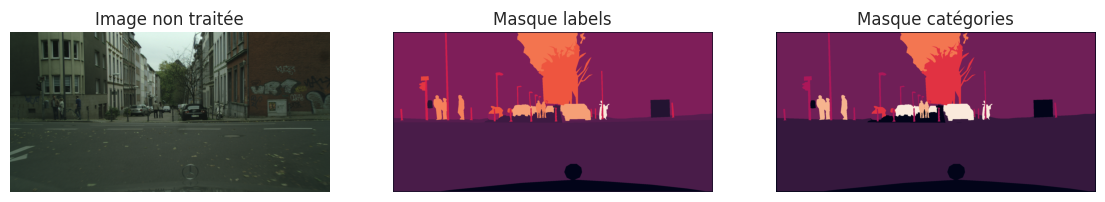

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))
for ax in axs:
	ax.axis("off")

axs[0].imshow(img)
axs[0].set_title("Image non traitée")

axs[1].imshow(mask)
axs[1].set_title("Masque labels")

axs[2].imshow(cat_mask	)
axs[2].set_title("Masque catégories")

plt.show()

C'est subtile, mais on peut voir par exemple que le scooter à droite de l'image est affiché d'une couleur différente dans le masque avec les labels, alors qu'il est de la même couleur dans le masque avec seulement les catégories.

## Mise en place du modèle

Maintenant que nous en savons plus sur nos images que la méthode pour passer des labels aux catégories est clair, nous pouvons mettre en place les ressources nécessaires à l'entraînement de notre modèle.

Commençons par l'héritance de la classe "Dataset" qui nour permettra de charger les images pour notre modèle.

In [7]:
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2


img_resize = (int(img.shape[0] / 4), int(img.shape[1] / 4))

img_transformer = v2.Compose([
	v2.Resize(img_resize, interpolation=v2.InterpolationMode.BILINEAR),
	v2.ToImage(),
	v2.ToDtype(torch.float32, scale=True)
])

mask_transformer = v2.Compose([
	v2.Resize(img_resize, interpolation=v2.InterpolationMode.NEAREST),
	v2.ToImage(),
	v2.ToDtype(torch.long)
])

class ImagesDataset(Dataset):
	
	def __init__(self, imgs_base_folder, folder_type, mapping_array, img_transformer, mask_transformer):

		self.imgs_folder = imgs_base_folder + "/" + folder_type + "/*/*"

		self.imgs_path = []
		for img_path in glob.glob(self.imgs_folder):
			self.imgs_path.append(img_path)
		
		self.mapping_array = torch.tensor(mapping_array, dtype=torch.long)
		self.img_transformer = img_transformer
		self.mask_transformer = mask_transformer
		
	def __len__ (self):
		return len(self.imgs_path)
		
	def __getitem__ (self, index):
		
		img_path = self.imgs_path[index]
		mask_path = img_path.replace("leftImg8bit", "gtFine")
		mask_path = mask_path.replace(".png", "_labelIds.png")

		img = Image.open(img_path)
		mask = Image.open(mask_path)

		img_tensor = self.img_transformer(img)
		mask_tensor = self.mask_transformer(mask).squeeze(0)

		mask_tensor = self.mapping_array[mask_tensor]

		return(img_tensor, mask_tensor)

Testons avec une image pour être sûr qu'il n'y ait pas d'erreur.

torch.Size([3, 256, 512])
torch.Size([256, 512])
tensor([0, 1, 2, 3, 4, 5, 6, 7])


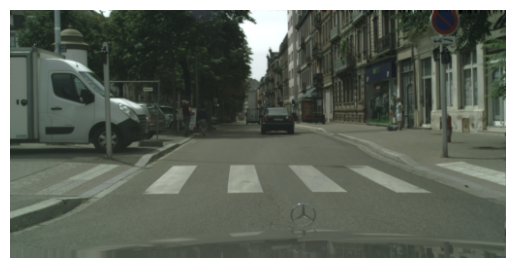

In [8]:
folder_path = "data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit"
test_tuple = ImagesDataset(folder_path, "train", MAPPING_ARRAY, img_transformer, mask_transformer)

test_img, test_mask = test_tuple[0]
print(test_img.shape)
print(test_mask.shape)
print(test_mask.unique())

plt.imshow(test_img.permute(1, 2, 0))
plt.axis(False)
plt.show()